In [1]:
print("hello world")

hello world


In [3]:
for i in range(5):
    print(i)

0
1
2
3
4


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# 1. Load the image
image_path = "/home/mohamed-alwathiq/Downloads/dish.jpg"
image = cv2.imread(image_path)
# OpenCV loads in BGR, Matplotlib expects RGB. Convert for displaying.
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# 2. Convert to Grayscale
# Math is faster and simpler on a 2D black-and-white array
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 3. Apply Gaussian Blur
# This smooths out microscopic dust so the computer doesn't overcount
blurred = cv2.GaussianBlur(gray, (15, 15), 0)

In [8]:


# 4. Otsu's Thresholding
# This automatically calculates the best lighting threshold to turn the image 
# into pure black (background) and pure white (colonies)
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. Find Contours
# The algorithm traces the boundaries of the white blobs
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 6. Filter by size and draw
min_area = 50  # Ignore tiny specs
valid_colonies = [c for c in contours if cv2.contourArea(c) > min_area]

# Draw red outlines around detected colonies on a copy of the original image
output_image = image_rgb.copy()
cv2.drawContours(output_image, valid_colonies, -1, (255, 0, 0), 2)

print(f"Total isolated colonies detected: {len(valid_colonies)}")



Total isolated colonies detected: 3


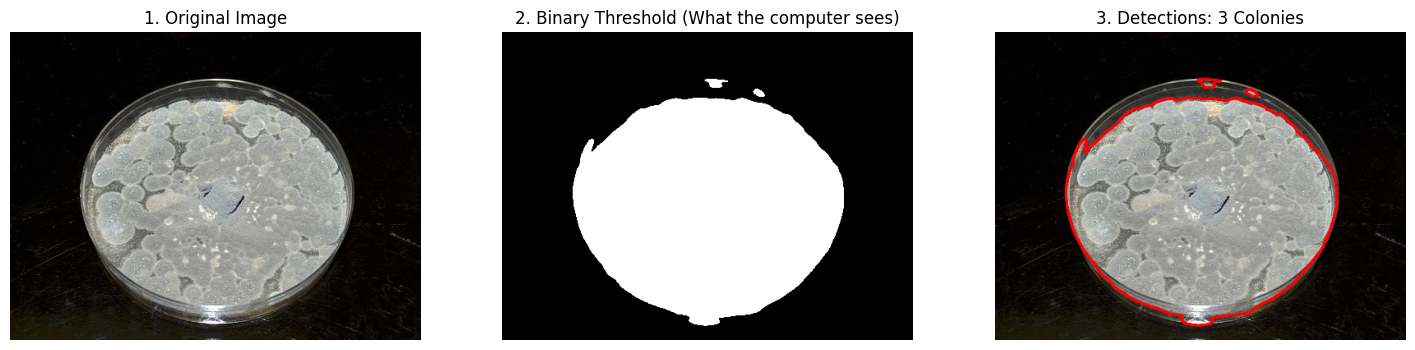

In [10]:
# 7. Visualize the pipeline
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].imshow(image_rgb)
axs[0].set_title("1. Original Image")
axs[0].axis("off")

axs[1].imshow(thresh, cmap="gray")
axs[1].set_title("2. Binary Threshold (What the computer sees)")
axs[1].axis("off")

axs[2].imshow(output_image)
axs[2].set_title(f"3. Detections: {len(valid_colonies)} Colonies")
axs[2].axis("off")

plt.show()


image 1/1 /home/mohamed-alwathiq/Downloads/dish.jpg: 480x640 1 bowl, 1 dining table, 1 clock, 139.8ms
Speed: 6.2ms preprocess, 139.8ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 640)


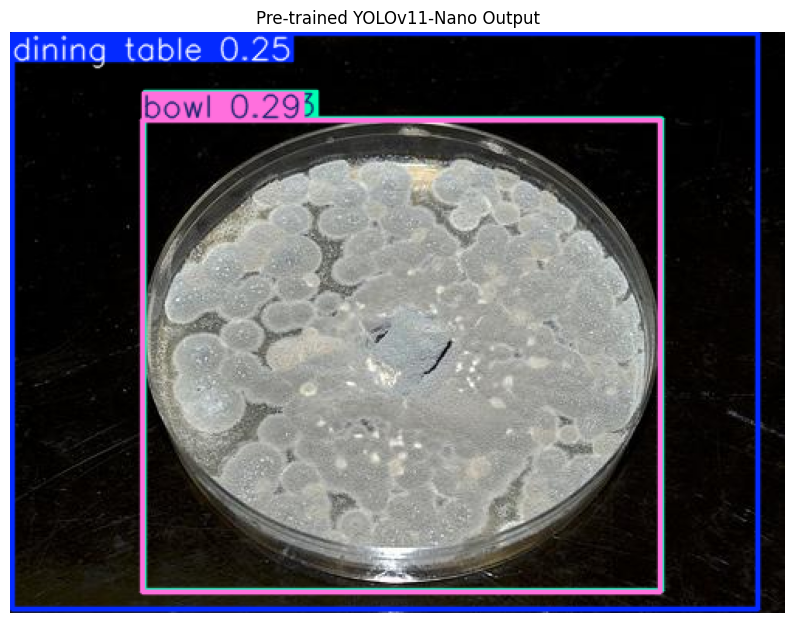

In [12]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

# 1. Load the pre-trained Nano model (downloads automatically the first time)
model = YOLO("yolo11n.pt")

# 2. Run inference on your sample image
# We set conf=0.1 just to see everything the model *thinks* it sees
results = model(image_path, conf=0.1)

# 3. Extract the image with the bounding boxes drawn on it
annotated_image = results[0].plot()

# 4. Display the result using Matplotlib
# Convert BGR (OpenCV format) to RGB (Matplotlib format)
annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_image_rgb)
plt.axis("off")
plt.title("Pre-trained YOLOv11-Nano Output")
plt.show()

In [27]:
!pip install ollama
import ollama
import json

In [30]:
# 1. Mock the Data (This simulates the output we will eventually get from OpenCV + YOLO)
# We format it as a JSON string because LLMs parse structured data very well.
mock_vision_data = {
    "colony_count": 84,
    "contaminants": 1,
    "density_flag": "High"
}

vision_json_string = json.dumps(mock_vision_data)

# 2. Design the System Prompt
# This tells the Qwen model exactly how to behave and formats its output.
system_prompt = """
You are LabLens, an AI-powered microbiology assistant. 
Your job is to read raw JSON sensor data from a petri dish analysis and generate a concise, professional lab notebook entry.
Format the output with clear bullet points. Do not include conversational filler.
"""

print("Sending mocked JSON data to local Qwen2.5-1.5B model...\n")

# 3. Call the Local LLM
response = ollama.chat(model='llama3.2', messages=[
  {
    'role': 'system',
    'content': system_prompt
  },
  {
    'role': 'user',
    'content': f"Here is the latest sensor data: {vision_json_string}"
  }
])

# 4. Display the Output
print("====== GENERATED LAB NOTES ======")
print(response['message']['content'])
print("=================================")

Sending mocked JSON data to local Qwen2.5-1.5B model...

====== GENERATED LAB NOTES ======
**Petri Dish Analysis Lab Notebook Entry**

* **Colony Count:** 84
* **Contamination:** 1
  + Type of Contaminant: Unknown/Unidentified (Further analysis required)
* **Density Flag:** High
* **Observations:** A high-density colony growth is observed, with an isolated contaminant present. Further investigation and analysis are necessary to determine the type and potential impact of the contaminant.

**Recommendations:**

* Re-inspect the petri dish under magnification to confirm the presence of the contaminant.
* Consider re-streaking or re-culturing the colony to assess its viability and potential application.
* Take additional samples for further analysis, including Gram staining and biochemical testing.


In [17]:
pip install -U inference-sdk


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 698.8 kB/s eta 0:00:001m713.2 kB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.2/94.2 kB 13.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 2.2 MB/s eta 0:00:002.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 1.9 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 552.4 kB/s eta 0:00:00m eta 0:00:010:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 799.7 kB/s eta 0:00:00MB/s eta 0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 954.1 kB/s eta 0:00:00 kB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
  

In [18]:
# 1. Import the library
from inference_sdk import InferenceHTTPClient

# 2. Connect to your workflow
client = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="UFkIgVDpJOe70zZ80m3R"
)

# 3. Run your workflow on an image
result = client.run_workflow(
    workspace_name="mohamed-alwathiq-s-workspace",
    workflow_id="petri-dish-contamination-detection-1779520779273",
    images={
        "image": "YOUR_IMAGE.jpg" # Path to your image file
    },
    use_cache=True # Speeds up repeated requests
)

# 4. Get your results
print(result)


HTTPCallErrorError: HTTPCallErrorError(description='400 Client Error: Bad Request for url: https://serverless.roboflow.com/mohamed-alwathiq-s-workspace/workflows/petri-dish-contamination-detection-1779520779273', api_message='Failed to assemble `image`. Could not successfully use any deserializer for declared kinds. Details: 
Kind: `image` - Error: Detected runtime parameter `image` defined as `WorkflowImage` that is invalid. Failed on input validation. Details: NumPy image type is not supported in this configuration of `inference`.. More details: None',status_code=400)

Loading Custom LabLens Model...

image 1/10 /home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/4826.jpg: 640x576 11 colonys, 233.5ms
image 2/10 /home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/4904.jpg: 640x544 33 colonys, 213.2ms
image 3/10 /home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/5206.jpg: 640x576 101 colonys, 140.6ms
image 4/10 /home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/5207.jpg: 640x576 6 colonys, 127.7ms
image 5/10 /home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/5212.jpg: 640x576 41 colonys, 94.7ms
image 6/10 /home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/5270.jpg: 640x576 44 colonys, 127.6ms
image 7/10 /home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/5271.jpg: 640x544 42 colonys, 101.9ms
image 8/10 /home/mohame

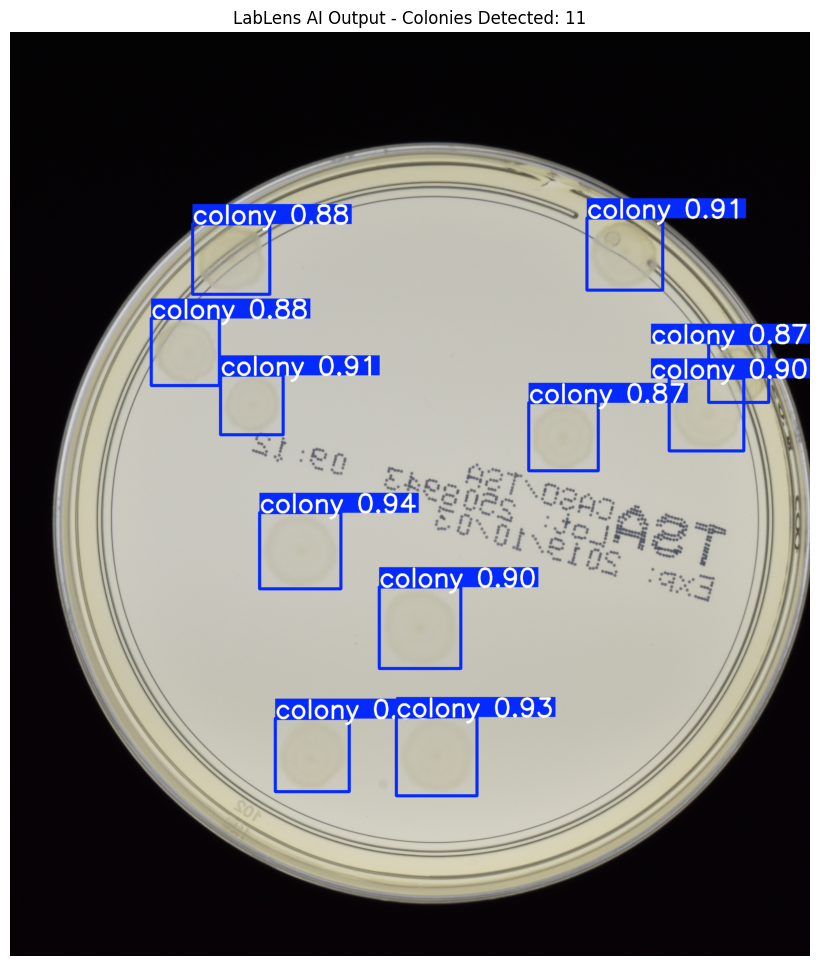

In [20]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2

print("Loading Custom LabLens Model...")

# 1. Load your newly trained local model
model = YOLO("models/lablens_v1.pt")

# 2. Run inference on the challenging image
# Setting conf=0.25 filters out weak, uncertain guesses
image_path = "/home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/" 
results = model(image_path, conf=0.25)

# 3. Parse and count the detected objects
boxes = results[0].boxes
class_ids = boxes.cls.cpu().numpy()  # Get the numerical IDs of what was found
names = model.names                  # Get the dictionary of class names (e.g., 0: 'colony')

# Create a dictionary to keep track of the counts
counts = {name: 0 for name in names.values()}
for cls_id in class_ids:
    class_name = names[int(cls_id)]
    counts[class_name] += 1

print("\n=== LABLENS SENSOR DATA ===")
for name, count in counts.items():
    print(f"{name.capitalize()}: {count}")
print("===========================\n")

# 4. Visualize the "Aha!" Moment
annotated_img = results[0].plot() # This automatically draws the boxes and labels!
annotated_img_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 12))
plt.imshow(annotated_img_rgb)
plt.axis("off")
plt.title(f"LabLens AI Output - Colonies Detected: {counts.get('colony', 0)}")
plt.show()

In [23]:
from ultralytics import YOLO
import ollama
import json




In [24]:
print("Initializing LabLens Pipeline...\n")

# --- STEP 1: VISION ENGINE ---
# Load your custom YOLO model
vision_model = YOLO("models/lablens_v1.pt")

# Analyze the image (Change this path to test different plates)
image_path = "/home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/"
print(f"Scanning {image_path} with YOLOv11...")
results = vision_model(image_path, conf=0.25, verbose=False)

# Extract counts
boxes = results[0].boxes
class_ids = boxes.cls.cpu().numpy()
names = vision_model.names

# Initialize counters based on your classes
sensor_data = {"colony": 0, "contamination": 0, "defect": 0}
for cls_id in class_ids:
    class_name = names[int(cls_id)]
    if class_name in sensor_data:
        sensor_data[class_name] += 1

print("\n[Vision Output Extracted]")
print(json.dumps(sensor_data, indent=2))

Initializing LabLens Pipeline...

Scanning /home/mohamed-alwathiq/Downloads/AGAR_demo/AGAR_representative/higher-resolution/dark/ with YOLOv11...

[Vision Output Extracted]
{
  "colony": 11,
  "contamination": 0,
  "defect": 0
}


In [29]:


# --- STEP 2: REASONING ENGINE ---
print("\nDrafting report with llama3.2..\n")

# Strict prompt to prevent the hallucination we saw in Milestone 3
system_prompt = (
    "You are LabLens, an AI microbiology assistant. "
    "Write a concise, 3-sentence lab notebook entry based ONLY on the provided JSON sensor data. "
    "Do NOT invent dates, temperature, humidity, or any other metrics not present in the JSON. "
    "State the counts clearly and note if the plate is clean or requires quarantine based on contamination."
)

user_prompt = f"Raw Sensor Data: {json.dumps(sensor_data)}"

# Call the local Ollama service
response = ollama.chat(model='llama3.2', messages=[
  {'role': 'system', 'content': system_prompt},
  {'role': 'user', 'content': user_prompt}
])

# --- STEP 3: FINAL OUTPUT ---
print("====================================")
print("     LABLENS AUTOMATED REPORT       ")
print("====================================")
print(response['message']['content'])
print("====================================")


Drafting report with llama3.2..

     LABLENS AUTOMATED REPORT       
Lab Notebook Entry:

- Plate status: Clean
- Colony count: 11
- Contamination level: 0, no need for quarantine.


In [31]:
import ollama

system_prompt = """You are LabLens, a professional AI microbiology assistant.
Write concise, structured lab notebook entries based ONLY on the data provided.
Do not invent or assume any values not explicitly given.
If contamination > 0, flag it clearly and recommend action."""

user_prompt = """{
    "colony_count": 47,
    "contaminants": 2,
    "defects": 0,
    "timestamp": "2026-05-23 21:00"
}"""

response = ollama.chat(model='llama3.2', messages=[
    {'role': 'system', 'content': system_prompt},
    {'role': 'user', 'content': user_prompt}
])

print(response['message']['content'])

**Lab Notebook Entry - May 23, 2026**

**Sample ID:** Not provided (please specify)

**Observations:**

* Total colony count: **47**
* Presence of contaminants detected: **2**
	+ Recommendation: Discard sample and re-purify. Potential for spoilage or contamination.

**Defects:** None

**Timestamp:** 2026-05-23 21:00
